# LunarLander-v3: comparación experimental de políticas

**Práctica 2 de Aprendizaje por Refuerzo Profundo**

En este cuaderno se estudia la versión discreta de `LunarLander-v3`. Primero se establece una referencia aleatoria y después se entrenan DQN, PPO y A2C. Finalmente se añade QR-DQN como experimento complementario, motivado por la inestabilidad observada en A2C.

Todos los agentes se comparan sobre las mismas 30 semillas (`1000`–`1029`). Para evitar que una evaluación favorable o un vídeo vistoso oculten la variabilidad real, la selección final se basa en los mejores checkpoints y en una evaluación común, no en un único episodio.

## 1. Configuración del experimento

El notebook está preparado para reutilizar los artefactos ya generados. Los entrenamientos largos y la regeneración de vídeos permanecen desactivados por defecto; basta con cambiar las dos banderas siguientes para repetirlos. Así, ejecutar el cuaderno no sobrescribe accidentalmente modelos ni vídeos.

In [1]:
import random
import time
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from gymnasium.wrappers import RecordVideo
from IPython.display import Video, display

from stable_baselines3 import A2C, DQN, PPO
from stable_baselines3.common.callbacks import CallbackList, CheckpointCallback, EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.sb2_compat.rmsprop_tf_like import RMSpropTFLike

try:
    from sb3_contrib import QRDQN
except ImportError:
    QRDQN = None

print("Gymnasium:", gym.__version__)
print("PyTorch:", torch.__version__)

Gymnasium: 1.3.0
PyTorch: 2.13.0+cu130


In [2]:
ID_ENTORNO = "LunarLander-v3"
SEMILLA = 42
N_EPISODIOS_EVALUACION = 30
SEMILLAS_EVALUACION = list(range(1000, 1030))
DEVICE = "cpu"

EJECUTAR_ENTRENAMIENTOS = False
REGENERAR_VIDEOS = False

# Directorios para poder correr desde raíz
candidatos_raiz = [Path.cwd(), Path.cwd().parent]
RAIZ_PROYECTO = next(
    (ruta for ruta in candidatos_raiz if (ruta / "resultados_lunarlander").exists()),
    Path.cwd(),
)
BASE_DIR = RAIZ_PROYECTO / "resultados_lunarlander"

RUTAS = {
    "aleatoria": BASE_DIR / "politica_aleatoria",
    "dqn": BASE_DIR / "dqn",
    "ppo": BASE_DIR / "ppo",
    "a2c": BASE_DIR / "a2c",
    "a2c_ajustado": BASE_DIR / "a2c_ajustado",
    "a2c_nocturno": BASE_DIR / "a2c_nocturno",
    "qrdqn": BASE_DIR / "qrdqn",
    "comparacion": BASE_DIR / "comparacion",
}

for ruta in RUTAS.values():
    ruta.mkdir(parents=True, exist_ok=True)

for clave in ["dqn", "ppo", "a2c", "a2c_ajustado", "qrdqn"]:
    for subcarpeta in ["modelos", "modelos/checkpoints", "evaluaciones", "logs", "videos"]:
        (RUTAS[clave] / subcarpeta).mkdir(parents=True, exist_ok=True)

(RUTAS["aleatoria"] / "videos").mkdir(parents=True, exist_ok=True)

random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

especificacion = gym.spec(ID_ENTORNO)
UMBRAL_RESUELTO = float(especificacion.reward_threshold)
MAX_PASOS = int(especificacion.max_episode_steps)

print("Raíz del proyecto:", RAIZ_PROYECTO)
print("Umbral oficial:", UMBRAL_RESUELTO)
print("Máximo de pasos:", MAX_PASOS)
print("Entrenamientos activados:", EJECUTAR_ENTRENAMIENTOS)

Raíz del proyecto: /home/andy/Descargas/AR_practica2/lunarlander
Umbral oficial: 200.0
Máximo de pasos: 1000
Entrenamientos activados: False


In [3]:
from pathlib import Path

print("Directorio actual:")
print(Path.cwd().resolve())

print("\nRaíz detectada por el notebook:")
print(RAIZ_PROYECTO.resolve())

print("\nCarpeta de resultados utilizada:")
print(BASE_DIR.resolve())

print("\n¿Existe esa carpeta?:")
print(BASE_DIR.exists())

print("\nContenido directo de la carpeta utilizada:")
if BASE_DIR.exists():
    for ruta in sorted(BASE_DIR.iterdir()):
        tipo = "carpeta" if ruta.is_dir() else "archivo"
        print(f"- {tipo}: {ruta.name}")

print("\nCarpetas resultados_lunarlander cercanas:")
carpetas_encontradas = set()

for origen in [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.home() / "Descargas",
]:
    if origen.exists():
        for ruta in origen.glob("**/resultados_lunarlander"):
            carpetas_encontradas.add(ruta.resolve())

for ruta in sorted(carpetas_encontradas):
    numero_archivos = sum(
        1 for archivo in ruta.rglob("*") if archivo.is_file()
    )
    print(f"- {ruta} → {numero_archivos} archivos")

Directorio actual:
/home/andy/Descargas/AR_practica2/lunarlander/notebooks

Raíz detectada por el notebook:
/home/andy/Descargas/AR_practica2/lunarlander

Carpeta de resultados utilizada:
/home/andy/Descargas/AR_practica2/lunarlander/resultados_lunarlander

¿Existe esa carpeta?:
True

Contenido directo de la carpeta utilizada:
- carpeta: a2c
- carpeta: a2c_ajustado
- carpeta: a2c_nocturno
- carpeta: comparacion
- carpeta: dqn
- carpeta: politica_aleatoria
- carpeta: ppo
- carpeta: qrdqn

Carpetas resultados_lunarlander cercanas:
- /home/andy/Descargas/AR_practica2/lunarlander/resultados_lunarlander → 168 archivos
- /home/andy/Descargas/AR_practica2/lunarlander/resultados_lunarlander/a2c/resultados_lunarlander → 5 archivos


### Comprobación de entorno

In [4]:
def crear_entorno(
    semilla: int | None = None,
    render_mode: str | None = None,
    monitor: bool = False,
):
    entorno = gym.make(
        ID_ENTORNO,
        continuous=False,
        render_mode=render_mode,
    )
    if monitor:
        entorno = Monitor(entorno)
    if semilla is not None:
        entorno.action_space.seed(semilla)
    return entorno


entorno_prueba = crear_entorno(semilla=SEMILLA, render_mode="rgb_array")
observacion, _ = entorno_prueba.reset(seed=SEMILLA)
fotograma = entorno_prueba.render()

print("Espacio de observaciones:", entorno_prueba.observation_space)
print("Espacio de acciones:", entorno_prueba.action_space)
print("Forma de la observación:", observacion.shape)
print("Forma del fotograma:", fotograma.shape)

assert observacion.shape == (8,)
assert entorno_prueba.action_space.n == 4
entorno_prueba.close()

Espacio de observaciones: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Espacio de acciones: Discrete(4)
Forma de la observación: (8,)
Forma del fotograma: (400, 600, 3)


### Funciones comunes

In [5]:
def programacion_lineal(valor_inicial: float):
    def funcion(progress_remaining: float) -> float:
        return progress_remaining * valor_inicial
    return funcion


def evaluar_politica_aleatoria(semillas: list[int]) -> pd.DataFrame:
    resultados = []

    for episodio, semilla in enumerate(semillas, start=1):
        entorno = crear_entorno(semilla=semilla)
        observacion, _ = entorno.reset(seed=semilla)
        recompensa_total = 0.0
        pasos = 0

        while True:
            accion = entorno.action_space.sample()
            observacion, recompensa, terminated, truncated, _ = entorno.step(accion)
            recompensa_total += recompensa
            pasos += 1

            if terminated or truncated:
                break

        entorno.close()
        resultados.append({
            "politica": "Aleatoria",
            "episodio": episodio,
            "semilla": semilla,
            "recompensa": recompensa_total,
            "pasos": pasos,
            "resuelto": recompensa_total >= UMBRAL_RESUELTO,
        })

    return pd.DataFrame(resultados)


def evaluar_modelo(modelo, nombre_modelo: str, semillas: list[int]) -> pd.DataFrame:
    resultados = []

    for episodio, semilla in enumerate(semillas, start=1):
        entorno = crear_entorno(semilla=semilla)
        observacion, _ = entorno.reset(seed=semilla)
        recompensa_total = 0.0
        pasos = 0

        while True:
            accion, _ = modelo.predict(observacion, deterministic=True)
            accion = int(np.asarray(accion).item())
            observacion, recompensa, terminated, truncated, _ = entorno.step(accion)
            recompensa_total += recompensa
            pasos += 1

            if terminated or truncated:
                break

        entorno.close()
        resultados.append({
            "modelo": nombre_modelo,
            "episodio": episodio,
            "semilla": semilla,
            "recompensa": recompensa_total,
            "pasos": pasos,
            "resuelto": recompensa_total >= UMBRAL_RESUELTO,
        })

    return pd.DataFrame(resultados)


def resumir_resultados(resultados: pd.DataFrame, nombre: str) -> pd.DataFrame:
    media = resultados["recompensa"].mean()
    return pd.DataFrame([{
        "modelo": nombre,
        "recompensa_media": media,
        "desviacion_tipica": resultados["recompensa"].std(ddof=0),
        "minimo": resultados["recompensa"].min(),
        "maximo": resultados["recompensa"].max(),
        "episodios_resueltos": int(resultados["resuelto"].sum()),
        "porcentaje_exito": 100 * resultados["resuelto"].mean(),
        "pasos_medios": resultados["pasos"].mean(),
        "resuelve_en_promedio": media >= UMBRAL_RESUELTO,
    }])


def cargar_curva(ruta_npz: Path):
    datos = np.load(ruta_npz)
    timesteps = datos["timesteps"]
    resultados = datos["results"]
    medias = resultados.mean(axis=1)
    desviaciones = resultados.std(axis=1, ddof=0)
    indice_mejor = int(np.argmax(medias))
    return timesteps, medias, desviaciones, indice_mejor


def evaluar_modelo_con_estado_final(modelo, nombre_modelo: str, semillas: list[int]):
    resultados = []

    for episodio, semilla in enumerate(semillas, start=1):
        entorno = crear_entorno(semilla=semilla)
        observacion, _ = entorno.reset(seed=semilla)
        recompensa_total = 0.0
        pasos = 0

        while True:
            accion, _ = modelo.predict(observacion, deterministic=True)
            accion = int(np.asarray(accion).item())
            observacion, recompensa, terminated, truncated, _ = entorno.step(accion)
            recompensa_total += recompensa
            pasos += 1

            if terminated or truncated:
                break

        entorno.close()
        resultados.append({
            "modelo": nombre_modelo,
            "episodio": episodio,
            "semilla": semilla,
            "recompensa": recompensa_total,
            "pasos": pasos,
            "resuelto": recompensa_total >= UMBRAL_RESUELTO,
            "posicion_x_final": float(observacion[0]),
            "posicion_y_final": float(observacion[1]),
            "angulo_final": float(observacion[4]),
            "pata_izquierda": bool(observacion[6]),
            "pata_derecha": bool(observacion[7]),
        })

    return pd.DataFrame(resultados)

def seleccionar_aterrizaje_centrado(resultados_detallados: pd.DataFrame):
    candidatos = resultados_detallados.loc[
        (resultados_detallados["recompensa"] >= UMBRAL_RESUELTO)
        & resultados_detallados["pata_izquierda"]
        & resultados_detallados["pata_derecha"]
    ].copy()

    if candidatos.empty:
        return resultados_detallados.loc[resultados_detallados["recompensa"].idxmax()]

    candidatos["distancia_centro"] = candidatos["posicion_x_final"].abs()
    return candidatos.sort_values(
        ["distancia_centro", "recompensa"],
        ascending=[True, False],
    ).iloc[0]


def grabar_video(modelo, semilla: int, carpeta: Path, prefijo: str):
    carpeta.mkdir(parents=True, exist_ok=True)
    entorno = gym.make(ID_ENTORNO, continuous=False, render_mode="rgb_array")
    entorno = RecordVideo(
        entorno,
        video_folder=str(carpeta),
        episode_trigger=lambda episodio: episodio == 0,
        name_prefix=prefijo,
    )

    observacion, _ = entorno.reset(seed=semilla)
    recompensa_total = 0.0

    while True:
        accion, _ = modelo.predict(observacion, deterministic=True)
        accion = int(np.asarray(accion).item())
        observacion, recompensa, terminated, truncated, _ = entorno.step(accion)
        recompensa_total += recompensa
        if terminated or truncated:
            break

    entorno.close()
    return recompensa_total

## 2. Política aleatoria: línea base

La política aleatoria ignora el estado de la nave y escoge una acción al azar.

In [6]:
ruta_resultados_aleatorios = RUTAS["aleatoria"] / "resultados_episodios_aleatorios.csv"

if ruta_resultados_aleatorios.exists():
    resultados_aleatorios = pd.read_csv(ruta_resultados_aleatorios)
else:
    resultados_aleatorios = evaluar_politica_aleatoria(SEMILLAS_EVALUACION)
    resultados_aleatorios.to_csv(ruta_resultados_aleatorios, index=False)

resumen_aleatorio = resumir_resultados(
    resultados_aleatorios,
    "Política aleatoria",
)
display(resumen_aleatorio.round(2))

,modelo,recompensa_media,desviacion_tipica,minimo,maximo,episodios_resueltos,porcentaje_exito,pasos_medios,resuelve_en_promedio
0,Política aleatoria,-229.32,107.58,-510.2,-76.22,0,0.0,99.03,False


In [7]:
# Vídeo política aleatoria

SEMILLA_VIDEO_REFERENCIA = 1009

carpeta_video_aleatorio = (
    RUTAS["aleatoria"] / "videos"
)

carpeta_video_aleatorio.mkdir(
    parents=True,
    exist_ok=True
)

ruta_video_aleatorio = (
    carpeta_video_aleatorio
    / "lunarlander_politica_aleatoria-episode-0.mp4"
)

# Se genera si falta. REGENERAR_VIDEOS permite sustituirlo voluntariamente.
if REGENERAR_VIDEOS or not ruta_video_aleatorio.exists():

    entorno_video_aleatorio = gym.make(
        ID_ENTORNO,
        continuous=False,
        render_mode="rgb_array"
    )

    entorno_video_aleatorio = RecordVideo(
        entorno_video_aleatorio,
        video_folder=str(carpeta_video_aleatorio),
        episode_trigger=lambda episodio: episodio == 0,
        name_prefix="lunarlander_politica_aleatoria"
    )

    observacion, info = entorno_video_aleatorio.reset(
        seed=SEMILLA_VIDEO_REFERENCIA
    )

    # También fijamos la secuencia de acciones aleatorias.
    entorno_video_aleatorio.action_space.seed(
        SEMILLA_VIDEO_REFERENCIA
    )

    recompensa_total_video = 0.0
    pasos_video = 0

    while True:
        accion = entorno_video_aleatorio.action_space.sample()

        observacion, recompensa, terminated, truncated, info = (
            entorno_video_aleatorio.step(accion)
        )

        recompensa_total_video += recompensa
        pasos_video += 1

        if terminated or truncated:
            break

    entorno_video_aleatorio.close()

    print("Vídeo aleatorio generado")
    print("Semilla:", SEMILLA_VIDEO_REFERENCIA)
    print("Pasos:", pasos_video)
    print("Recompensa:", round(recompensa_total_video, 2))

else:
    print("Se reutiliza el vídeo aleatorio existente.")

Se reutiliza el vídeo aleatorio existente.


In [8]:
videos_aleatorios = sorted(
    carpeta_video_aleatorio.glob(
        "lunarlander_politica_aleatoria*.mp4"
    )
)

if not videos_aleatorios:
    raise FileNotFoundError(
        f"No se encontró ningún vídeo en "
        f"{carpeta_video_aleatorio.resolve()}"
    )

ruta_video_aleatorio = videos_aleatorios[-1]

print("Vídeo utilizado:")
print(ruta_video_aleatorio.resolve())

display(
    Video(
        str(ruta_video_aleatorio),
        embed=True
    )
)

Vídeo utilizado:
/home/andy/Descargas/AR_practica2/lunarlander/resultados_lunarlander/politica_aleatoria/videos/lunarlander_politica_aleatoria-episode-0.mp4


La política aleatoria obtuvo una recompensa media de **-229.32** y no resolvió ninguno de los 30 episodios. El vídeo usa la semilla `1009`, que después se reutiliza con DQN para partir de la misma situación inicial.

## 3. DQN

DQN es adecuado para un espacio de acciones discreto: la red recibe los ocho valores del estado y estima un valor \(Q\) para cada una de las cuatro acciones. Se entrena una sola instancia y `EvalCallback` conserva el checkpoint con mayor recompensa media.

In [9]:
TOTAL_TIMESTEPS_DQN = 100_000
RUTA_DQN = RUTAS["dqn"]

if EJECUTAR_ENTRENAMIENTOS:
    entorno_dqn = crear_entorno(semilla=SEMILLA, monitor=True)
    entorno_eval_dqn = crear_entorno(semilla=SEMILLA + 1, monitor=True)

    callback_dqn = EvalCallback(
        entorno_eval_dqn,
        best_model_save_path=str(RUTA_DQN / "modelos"),
        log_path=str(RUTA_DQN / "evaluaciones"),
        eval_freq=5_000,
        n_eval_episodes=10,
        deterministic=True,
        verbose=1,
    )

    modelo_dqn = DQN(
        "MlpPolicy",
        entorno_dqn,
        learning_rate=6.3e-4,
        buffer_size=50_000,
        learning_starts=0,
        batch_size=128,
        gamma=0.99,
        train_freq=4,
        gradient_steps=-1,
        target_update_interval=250,
        exploration_fraction=0.12,
        exploration_final_eps=0.10,
        policy_kwargs={"net_arch": [256, 256]},
        tensorboard_log=str(RUTA_DQN / "logs"),
        seed=SEMILLA,
        device=DEVICE,
        verbose=1,
    )

    inicio = time.time()
    modelo_dqn.learn(TOTAL_TIMESTEPS_DQN, callback=callback_dqn, progress_bar=True)
    duracion_dqn = time.time() - inicio
    modelo_dqn.save(RUTA_DQN / "modelos" / "dqn_lunarlander_final")
    entorno_dqn.close()
    entorno_eval_dqn.close()
else:
    print("Se reutiliza el entrenamiento DQN ya guardado (100.000 pasos).")

Se reutiliza el entrenamiento DQN ya guardado (100.000 pasos).


In [10]:
resultados_dqn = pd.read_csv(RUTA_DQN / "resultados_episodios_dqn.csv")
resumen_dqn = pd.read_csv(RUTA_DQN / "resumen_evaluacion_dqn.csv")
fallos_dqn = pd.read_csv(RUTA_DQN / "episodios_no_resueltos_dqn.csv")

display(resumen_dqn.round(2))
display(fallos_dqn.round(2))

,modelo,recompensa_media,desviacion_tipica,minimo,maximo,episodios_resueltos,porcentaje_exito,pasos_medios
0,DQN - mejor checkpoint,248.23,42.4,71.65,296.45,27,90.0,347.73


,episodio,semilla,recompensa,pasos
0,14,1013,71.65,233
1,22,1021,196.25,698
2,28,1027,183.59,693


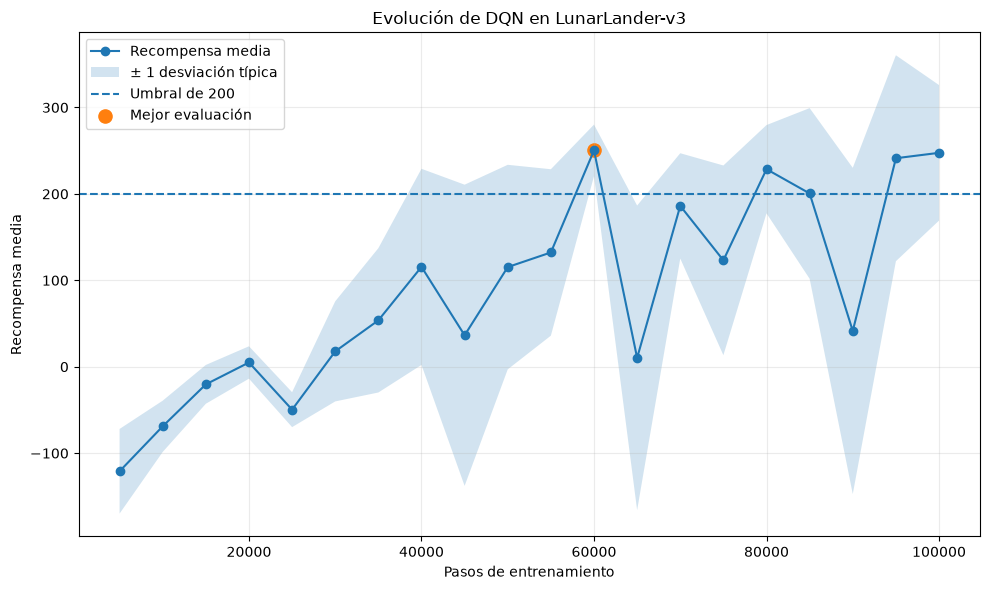

In [11]:
timesteps_dqn, medias_dqn, desviaciones_dqn, indice_mejor_dqn = cargar_curva(
    RUTA_DQN / "evaluaciones" / "evaluations.npz"
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(timesteps_dqn, medias_dqn, marker="o", label="Recompensa media")
ax.fill_between(
    timesteps_dqn,
    medias_dqn - desviaciones_dqn,
    medias_dqn + desviaciones_dqn,
    alpha=0.20,
    label="± 1 desviación típica",
)
ax.axhline(UMBRAL_RESUELTO, linestyle="--", label="Umbral de 200")
ax.scatter(
    timesteps_dqn[indice_mejor_dqn],
    medias_dqn[indice_mejor_dqn],
    s=90,
    label="Mejor evaluación",
)
ax.set(
    title="Evolución de DQN en LunarLander-v3",
    xlabel="Pasos de entrenamiento",
    ylabel="Recompensa media",
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

In [12]:
SEMILLA_VIDEO_DQN = 1009
ruta_video_dqn = RUTA_DQN / "videos" / "lunarlander_dqn_mejor-episode-0.mp4"

if REGENERAR_VIDEOS:
    modelo_mejor_dqn = DQN.load(RUTA_DQN / "modelos" / "best_model.zip", device=DEVICE)
    grabar_video(
        modelo_mejor_dqn,
        SEMILLA_VIDEO_DQN,
        RUTA_DQN / "videos",
        "lunarlander_dqn_mejor",
    )

display(Video(str(ruta_video_dqn), embed=True))

**Lectura del resultado.** DQN obtuvo **248.23 ± 42.40** y resolvió **27/30 episodios (90 %)**. Los tres fallos se conservan con sus semillas para analizarlos en la memoria. Fue el único método cuya recompensa media superó el umbral oficial.

## 4. PPO

PPO aprende directamente una política y una función de valor. Se utilizaron 16 entornos paralelos para recoger experiencia y un millón de pasos, con la intención de darle tiempo suficiente para estabilizarse.

| Parámetro | Valor |
|---|---:|
| Pasos | 1.000.000 |
| Entornos | 16 |
| `n_steps` | 1.024 |
| Batch | 64 |
| Épocas por actualización | 4 |
| \(\gamma\) | 0,999 |
| `gae_lambda` | 0,98 |
| Entropía | 0,01 |

In [13]:
TOTAL_TIMESTEPS_PPO = 1_000_000
N_ENVS_PPO = 16
RUTA_PPO = RUTAS["ppo"]

if EJECUTAR_ENTRENAMIENTOS:
    entorno_ppo = make_vec_env(
        ID_ENTORNO,
        n_envs=N_ENVS_PPO,
        seed=SEMILLA,
        env_kwargs={"continuous": False},
        monitor_dir=str(RUTA_PPO / "logs" / "entrenamiento"),
    )
    entorno_eval_ppo = make_vec_env(
        ID_ENTORNO,
        n_envs=1,
        seed=SEMILLA + 1,
        env_kwargs={"continuous": False},
        monitor_dir=str(RUTA_PPO / "logs" / "evaluacion"),
    )

    callback_ppo = CallbackList([
        EvalCallback(
            entorno_eval_ppo,
            best_model_save_path=str(RUTA_PPO / "modelos"),
            log_path=str(RUTA_PPO / "evaluaciones"),
            eval_freq=25_000 // N_ENVS_PPO,
            n_eval_episodes=10,
            deterministic=True,
            verbose=1,
        ),
        CheckpointCallback(
            save_freq=100_000 // N_ENVS_PPO,
            save_path=str(RUTA_PPO / "modelos" / "checkpoints"),
            name_prefix="ppo_lunarlander",
        ),
    ])

    modelo_ppo = PPO(
        "MlpPolicy",
        entorno_ppo,
        learning_rate=programacion_lineal(2.5e-4),
        n_steps=1024,
        batch_size=64,
        n_epochs=4,
        gamma=0.999,
        gae_lambda=0.98,
        clip_range=programacion_lineal(0.2),
        ent_coef=0.01,
        policy_kwargs={"net_arch": {"pi": [64, 64], "vf": [64, 64]}},
        tensorboard_log=str(RUTA_PPO / "logs" / "tensorboard"),
        seed=SEMILLA,
        device=DEVICE,
        verbose=1,
    )

    modelo_ppo.learn(TOTAL_TIMESTEPS_PPO, callback=callback_ppo, progress_bar=True)
    modelo_ppo.save(RUTA_PPO / "modelos" / "ppo_lunarlander_final")
    entorno_ppo.close()
    entorno_eval_ppo.close()
else:
    print("Se reutiliza el entrenamiento PPO ya guardado (1.000.000 de pasos).")

Se reutiliza el entrenamiento PPO ya guardado (1.000.000 de pasos).


In [14]:
resultados_ppo = pd.read_csv(RUTA_PPO / "resultados_episodios_ppo.csv")
resumen_ppo = pd.read_csv(RUTA_PPO / "resumen_evaluacion_ppo.csv")
fallos_ppo = pd.read_csv(RUTA_PPO / "episodios_no_resueltos_ppo.csv")

display(resumen_ppo.round(2))
display(fallos_ppo.round(2))

,modelo,recompensa_media,desviacion_tipica,minimo,maximo,episodios_resueltos,porcentaje_exito,pasos_medios
0,PPO - mejor checkpoint,159.7,108.21,-83.04,248.53,19,63.33,504.23


,episodio,semilla,recompensa,pasos
0,5,1004,-19.91,448
1,6,1005,198.76,502
2,10,1009,189.97,822
3,12,1011,189.51,503
4,15,1014,-82.78,401
5,19,1018,-37.54,399
6,21,1020,-35.94,479
7,22,1021,182.68,519
8,24,1023,-83.04,352
9,29,1028,182.01,475


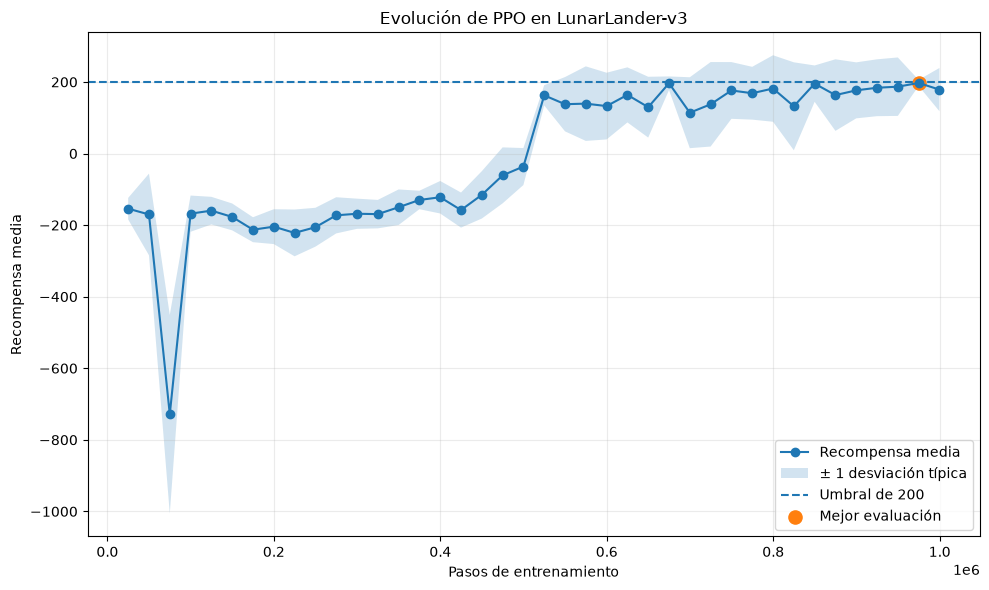

In [15]:
timesteps_ppo, medias_ppo, desviaciones_ppo, indice_mejor_ppo = cargar_curva(
    RUTA_PPO / "evaluaciones" / "evaluations.npz"
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(timesteps_ppo, medias_ppo, marker="o", label="Recompensa media")
ax.fill_between(
    timesteps_ppo,
    medias_ppo - desviaciones_ppo,
    medias_ppo + desviaciones_ppo,
    alpha=0.20,
    label="± 1 desviación típica",
)
ax.axhline(UMBRAL_RESUELTO, linestyle="--", label="Umbral de 200")
ax.scatter(
    timesteps_ppo[indice_mejor_ppo],
    medias_ppo[indice_mejor_ppo],
    s=90,
    label="Mejor evaluación",
)
ax.set(
    title="Evolución de PPO en LunarLander-v3",
    xlabel="Pasos de entrenamiento",
    ylabel="Recompensa media",
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

### Selección del vídeo de PPO

La primera selección se basó únicamente en un episodio resuelto cercano a la media. Al visualizarlo, la nave terminó fuera de las banderas. Por eso se descartó ese criterio como insuficiente y se repitió la búsqueda exigiendo ambas patas apoyadas y una posición final lo más próxima posible al centro.

El vídeo definitivo corresponde a la semilla `1027`: recompensa `210,99`, posición horizontal final `0,021` y ambas patas apoyadas. En el notebook limpio se conserva únicamente este vídeo final.

In [16]:
SEMILLA_VIDEO_PPO = 1027
ruta_video_ppo = RUTA_PPO / "videos" / "lunarlander_ppo_mejor-episode-0.mp4"

if REGENERAR_VIDEOS:
    modelo_mejor_ppo = PPO.load(RUTA_PPO / "modelos" / "best_model.zip", device=DEVICE)
    resultados_detallados = evaluar_modelo_con_estado_final(
        modelo_mejor_ppo,
        "PPO - mejor checkpoint",
        SEMILLAS_EVALUACION,
    )
    episodio = seleccionar_aterrizaje_centrado(resultados_detallados)
    SEMILLA_VIDEO_PPO = int(episodio["semilla"])
    grabar_video(
        modelo_mejor_ppo,
        SEMILLA_VIDEO_PPO,
        RUTA_PPO / "videos",
        "lunarlander_ppo_mejor",
    )

display(Video(str(ruta_video_ppo), embed=True))

**Lectura del resultado.** PPO obtuvo **159.70 ± 108.21** y resolvió **19/30 episodios (63,33 %)**. La curva terminó oscilando alrededor de valores parecidos: las últimas diez evaluaciones promediaron 176,40 puntos. Por ello no se prolongó el entrenamiento más allá de un millón de pasos.

## 5. A2C y análisis de sensibilidad

A2C también es actor-crítico, pero actualiza la política sin el mecanismo de recorte de PPO. La primera ejecución usó 16 entornos y 500.000 pasos.

| Parámetro | Valor |
|---|---:|
| Pasos | 500.000 |
| Entornos | 16 |
| `n_steps` | 5 |
| Tasa de aprendizaje | \(7\times10^{-4}\) |
| \(\gamma\) | 0,99 |
| `gae_lambda` | 1,0 |
| Entropía | 0,01 |

In [17]:
TOTAL_TIMESTEPS_A2C = 500_000
N_ENVS_A2C = 16
RUTA_A2C = RUTAS["a2c"]

if EJECUTAR_ENTRENAMIENTOS:
    entorno_a2c = make_vec_env(
        ID_ENTORNO,
        n_envs=N_ENVS_A2C,
        seed=SEMILLA,
        env_kwargs={"continuous": False},
        monitor_dir=str(RUTA_A2C / "logs" / "entrenamiento"),
    )
    entorno_eval_a2c = make_vec_env(
        ID_ENTORNO,
        n_envs=1,
        seed=SEMILLA + 1,
        env_kwargs={"continuous": False},
        monitor_dir=str(RUTA_A2C / "logs" / "evaluacion"),
    )

    callback_a2c = CallbackList([
        EvalCallback(
            entorno_eval_a2c,
            best_model_save_path=str(RUTA_A2C / "modelos"),
            log_path=str(RUTA_A2C / "evaluaciones"),
            eval_freq=25_000 // N_ENVS_A2C,
            n_eval_episodes=10,
            deterministic=True,
            verbose=1,
        ),
        CheckpointCallback(
            save_freq=100_000 // N_ENVS_A2C,
            save_path=str(RUTA_A2C / "modelos" / "checkpoints"),
            name_prefix="a2c_lunarlander",
        ),
    ])

    modelo_a2c = A2C(
        "MlpPolicy",
        entorno_a2c,
        learning_rate=7e-4,
        n_steps=5,
        gamma=0.99,
        gae_lambda=1.0,
        ent_coef=0.01,
        vf_coef=0.5,
        max_grad_norm=0.5,
        normalize_advantage=True,
        use_rms_prop=True,
        policy_kwargs={"net_arch": {"pi": [64, 64], "vf": [64, 64]}},
        tensorboard_log=str(RUTA_A2C / "logs" / "tensorboard"),
        seed=SEMILLA,
        device=DEVICE,
        verbose=1,
    )

    modelo_a2c.learn(TOTAL_TIMESTEPS_A2C, callback=callback_a2c)
    modelo_a2c.save(RUTA_A2C / "modelos" / "a2c_lunarlander_final")
    entorno_a2c.close()
    entorno_eval_a2c.close()
else:
    print("Se reutiliza el entrenamiento A2C inicial ya guardado (500.000 pasos).")

Se reutiliza el entrenamiento A2C inicial ya guardado (500.000 pasos).


In [18]:
resultados_a2c = pd.read_csv(RUTA_A2C / "resultados_episodios_a2c.csv")
resumen_a2c = pd.read_csv(RUTA_A2C / "resumen_evaluacion_a2c.csv")
fallos_a2c = pd.read_csv(RUTA_A2C / "episodios_no_resueltos_a2c.csv")

display(resumen_a2c.round(2))
display(fallos_a2c.round(2))

,modelo,recompensa_media,desviacion_tipica,minimo,maximo,episodios_resueltos,porcentaje_exito,pasos_medios
0,A2C - mejor checkpoint,67.47,139.46,-145.4,276.63,9,30.0,488.8


,episodio,semilla,recompensa,pasos
0,1,1000,21.22,160
1,2,1001,10.20,353
2,3,1002,-90.09,1000
3,5,1004,44.58,158
4,6,1005,183.64,533
5,8,1007,-20.05,274
6,9,1008,-119.32,1000
7,10,1009,-15.81,417
8,11,1010,170.73,1000
9,12,1011,-142.61,1000


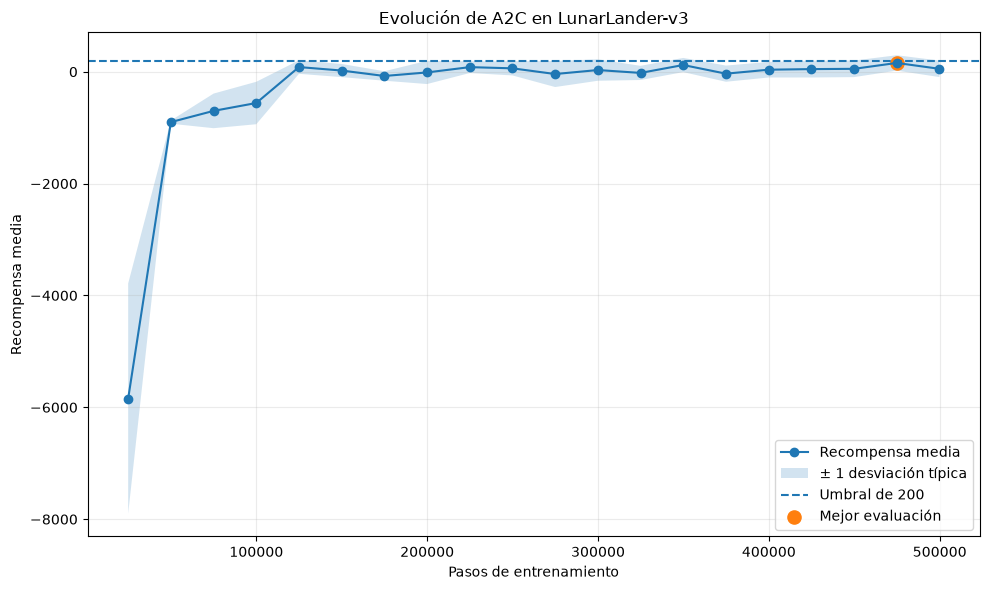

In [19]:
timesteps_a2c, medias_a2c, desviaciones_a2c, indice_mejor_a2c = cargar_curva(
    RUTA_A2C / "evaluaciones" / "evaluations.npz"
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(timesteps_a2c, medias_a2c, marker="o", label="Recompensa media")
ax.fill_between(
    timesteps_a2c,
    medias_a2c - desviaciones_a2c,
    medias_a2c + desviaciones_a2c,
    alpha=0.20,
    label="± 1 desviación típica",
)
ax.axhline(UMBRAL_RESUELTO, linestyle="--", label="Umbral de 200")
ax.scatter(
    timesteps_a2c[indice_mejor_a2c],
    medias_a2c[indice_mejor_a2c],
    s=90,
    label="Mejor evaluación",
)
ax.set(
    title="Evolución de A2C en LunarLander-v3",
    xlabel="Pasos de entrenamiento",
    ylabel="Recompensa media",
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

In [20]:
SEMILLA_VIDEO_A2C = 1017
ruta_video_a2c = RUTA_A2C / "videos" / "lunarlander_a2c_mejor-episode-0.mp4"
display(Video(str(ruta_video_a2c), embed=True))

El vídeo de A2C muestra uno de los nueve episodios que sí se resolvieron. Se conserva como demostración de que el agente llegó a aprender maniobras correctas, pero no debe interpretarse como su comportamiento habitual: la evaluación completa fue mucho más irregular.

### Por qué se repitió A2C

Durante una evaluación periódica reducida, A2C llegó a obtener 247,48 puntos y produjo un aterrizaje correcto. Sin embargo, el mejor checkpoint solo alcanzó 67,47 puntos de media en las 30 semillas comunes. La diferencia mostró que una evaluación puntual favorable no bastaba para afirmar que la política generalizaba.

Se realizó entonces una configuración ajustada de 200.000 pasos y, después, tres ejecuciones de 500.000 pasos con semillas distintas. Las pruebas nocturnas se resumen mediante la mejor media observada por el callback; no se presentan como evaluaciones finales sobre las 30 semillas comunes.

In [21]:
CONFIG_A2C_AJUSTADO = {
    "n_envs": 8,
    "learning_rate": 8.3e-4,
    "n_steps": 5,
    "gamma": 0.995,
    "ent_coef": 1e-5,
    "optimizer_class": RMSpropTFLike,
    "optimizer_eps": 1e-5,
}
SEMILLAS_A2C_ADICIONALES = [7, 123, 2026]

def entrenar_a2c_ajustado(semilla: int, timesteps: int, ruta: Path):
    # Reproduce una ejecución adicional sin mezclar sus artefactos.
    if not EJECUTAR_ENTRENAMIENTOS:
        print(
            f"Ejecución omitida: semilla={semilla}, timesteps={timesteps}. "
            "Activa EJECUTAR_ENTRENAMIENTOS para repetirla."
        )
        return None

    for subcarpeta in ["modelos", "evaluaciones"]:
        (ruta / subcarpeta).mkdir(parents=True, exist_ok=True)

    entorno = make_vec_env(
        ID_ENTORNO,
        n_envs=CONFIG_A2C_AJUSTADO["n_envs"],
        seed=semilla,
        env_kwargs={"continuous": False},
    )
    entorno_eval = make_vec_env(
        ID_ENTORNO,
        n_envs=1,
        seed=semilla + 10_000,
        env_kwargs={"continuous": False},
    )

    callback = EvalCallback(
        entorno_eval,
        best_model_save_path=str(ruta / "modelos"),
        log_path=str(ruta / "evaluaciones"),
        eval_freq=25_000 // CONFIG_A2C_AJUSTADO["n_envs"],
        n_eval_episodes=20,
        deterministic=True,
        verbose=1,
    )

    modelo = A2C(
        "MlpPolicy",
        entorno,
        learning_rate=programacion_lineal(CONFIG_A2C_AJUSTADO["learning_rate"]),
        n_steps=CONFIG_A2C_AJUSTADO["n_steps"],
        gamma=CONFIG_A2C_AJUSTADO["gamma"],
        ent_coef=CONFIG_A2C_AJUSTADO["ent_coef"],
        policy_kwargs={
            "optimizer_class": CONFIG_A2C_AJUSTADO["optimizer_class"],
            "optimizer_kwargs": {"eps": CONFIG_A2C_AJUSTADO["optimizer_eps"]},
        },
        seed=semilla,
        device=DEVICE,
        verbose=0,
    )

    modelo.learn(total_timesteps=timesteps, callback=callback)
    modelo.save(ruta / "modelos" / "modelo_final")
    entorno.close()
    entorno_eval.close()
    return modelo


print("Configuración ajustada y semillas adicionales documentadas.")

Configuración ajustada y semillas adicionales documentadas.


In [22]:
resumen_a2c_ajustado = pd.read_csv(
    RUTAS["a2c_ajustado"] / "resumen_evaluacion_a2c_ajustado.csv"
)
resumen_a2c_nocturno = pd.read_csv(
    RUTAS["a2c_nocturno"] / "resumen_entrenamientos.csv"
)

comparacion_sensibilidad_a2c = pd.DataFrame([
    {
        "configuracion": "Inicial",
        "semilla": 42,
        "timesteps": 500_000,
        "metrica": "Media final (30 semillas)",
        "recompensa": resumen_a2c.loc[0, "recompensa_media"],
        "exito_pct": resumen_a2c.loc[0, "porcentaje_exito"],
    },
    {
        "configuracion": "Ajustada",
        "semilla": 42,
        "timesteps": 200_000,
        "metrica": "Media final (30 semillas)",
        "recompensa": resumen_a2c_ajustado.loc[0, "recompensa_media"],
        "exito_pct": resumen_a2c_ajustado.loc[0, "porcentaje_exito"],
    },
])

repeticiones = resumen_a2c_nocturno.assign(
    configuracion="Ajustada, repetición",
    metrica="Mejor media del callback (20 episodios)",
    recompensa=lambda df: df["mejor_media_callback"],
    exito_pct=np.nan,
)[
    ["configuracion", "semilla", "timesteps", "metrica", "recompensa", "exito_pct"]
]

comparacion_sensibilidad_a2c = pd.concat(
    [comparacion_sensibilidad_a2c, repeticiones],
    ignore_index=True,
)

display(comparacion_sensibilidad_a2c.round(2))

,configuracion,semilla,timesteps,metrica,recompensa,exito_pct
0,Inicial,42,500000,Media final (30 semillas),67.47,30.0
1,Ajustada,42,200000,Media final (30 semillas),-508.59,0.0
2,"Ajustada, repetición",7,500000,Mejor media del callback (20 episodios),29.94,NaN
3,"Ajustada, repetición",123,500000,Mejor media del callback (20 episodios),-118.46,NaN
4,"Ajustada, repetición",2026,500000,Mejor media del callback (20 episodios),30.78,NaN


**Conclusión sobre A2C.** La configuración inicial fue la mejor de las probadas, pero solo resolvió **9/30 episodios** y obtuvo **67.47** puntos de media. Las variantes adicionales no ofrecieron una mejora consistente. La conclusión se limita a las configuraciones estudiadas: no significa que A2C sea incapaz de resolver LunarLander con cualquier combinación de hiperparámetros, sino que resultó el método más sensible e inestable en este experimento.

## 6. QR-DQN como experimento adicional

Tras comprobar la inestabilidad de A2C, se añadió QR-DQN sin sustituirlo en la comparación principal. QR-DQN extiende DQN modelando cuantiles de la distribución del retorno, en lugar de estimar únicamente su valor medio.

| Parámetro | Valor |
|---|---:|
| Pasos | 100.000 |
| Cuantiles | 170 |
| Replay buffer | 100.000 |
| Batch | 128 |
| \(\gamma\) | 0,995 |
| Red | [256, 256] |
| Evaluación | 20 episodios cada 10.000 pasos |

In [23]:
TOTAL_TIMESTEPS_QRDQN = 100_000
RUTA_QRDQN = RUTAS["qrdqn"]

if EJECUTAR_ENTRENAMIENTOS:
    if QRDQN is None:
        raise ImportError("Instala sb3-contrib para repetir QR-DQN.")

    entorno_qrdqn = crear_entorno(semilla=SEMILLA, monitor=True)
    entorno_eval_qrdqn = crear_entorno(semilla=SEMILLA + 1, monitor=True)

    callbacks_qrdqn = CallbackList([
        EvalCallback(
            entorno_eval_qrdqn,
            best_model_save_path=str(RUTA_QRDQN / "modelos"),
            log_path=str(RUTA_QRDQN / "evaluaciones"),
            eval_freq=10_000,
            n_eval_episodes=20,
            deterministic=True,
            verbose=1,
        ),
        CheckpointCallback(
            save_freq=50_000,
            save_path=str(RUTA_QRDQN / "modelos" / "checkpoints"),
            name_prefix="qrdqn_lunarlander",
        ),
    ])

    modelo_qrdqn = QRDQN(
        "MlpPolicy",
        entorno_qrdqn,
        learning_rate=programacion_lineal(1.5e-3),
        buffer_size=100_000,
        learning_starts=10_000,
        batch_size=128,
        gamma=0.995,
        train_freq=256,
        gradient_steps=-1,
        target_update_interval=1,
        exploration_fraction=0.24,
        exploration_final_eps=0.18,
        policy_kwargs={"net_arch": [256, 256], "n_quantiles": 170},
        tensorboard_log=str(RUTA_QRDQN / "logs"),
        seed=SEMILLA,
        device=DEVICE,
        verbose=1,
    )

    modelo_qrdqn.learn(TOTAL_TIMESTEPS_QRDQN, callback=callbacks_qrdqn, progress_bar=True)
    modelo_qrdqn.save(RUTA_QRDQN / "modelos" / "qrdqn_lunarlander_final")
    entorno_qrdqn.close()
    entorno_eval_qrdqn.close()
else:
    print("Se reutiliza el entrenamiento QR-DQN ya guardado (100.000 pasos).")

Se reutiliza el entrenamiento QR-DQN ya guardado (100.000 pasos).


In [24]:
resultados_qrdqn = pd.read_csv(RUTA_QRDQN / "resultados_episodios_qrdqn.csv")
resumen_qrdqn = pd.read_csv(RUTA_QRDQN / "resumen_evaluacion_qrdqn.csv")
fallos_qrdqn = pd.read_csv(RUTA_QRDQN / "episodios_no_resueltos_qrdqn.csv")

display(resumen_qrdqn.round(2))
display(fallos_qrdqn.round(2))

,modelo,recompensa_media,desviacion_tipica,minimo,maximo,episodios_resueltos,porcentaje_exito,pasos_medios,resuelve_en_promedio
0,QR-DQN - mejor checkpoint,198.04,119.12,-184.2,285.89,25,83.33,430.77,False


,episodio,semilla,recompensa,pasos
0,9,1008,-184.20,363
1,10,1009,155.99,840
2,11,1010,-173.10,447
3,13,1012,-66.51,236
4,19,1018,126.48,1000


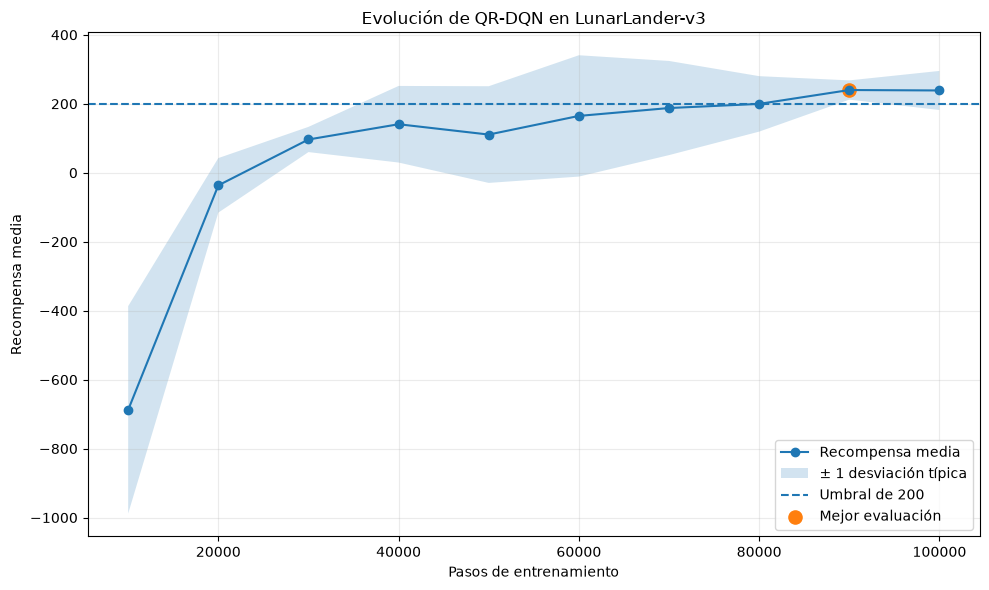

In [25]:
timesteps_qrdqn, medias_qrdqn, desviaciones_qrdqn, indice_mejor_qrdqn = cargar_curva(
    RUTA_QRDQN / "evaluaciones" / "evaluations.npz"
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(timesteps_qrdqn, medias_qrdqn, marker="o", label="Recompensa media")
ax.fill_between(
    timesteps_qrdqn,
    medias_qrdqn - desviaciones_qrdqn,
    medias_qrdqn + desviaciones_qrdqn,
    alpha=0.20,
    label="± 1 desviación típica",
)
ax.axhline(UMBRAL_RESUELTO, linestyle="--", label="Umbral de 200")
ax.scatter(
    timesteps_qrdqn[indice_mejor_qrdqn],
    medias_qrdqn[indice_mejor_qrdqn],
    s=90,
    label="Mejor evaluación",
)
ax.set(
    title="Evolución de QR-DQN en LunarLander-v3",
    xlabel="Pasos de entrenamiento",
    ylabel="Recompensa media",
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

In [26]:
SEMILLA_VIDEO_QRDQN = 1027
ruta_video_qrdqn = RUTA_QRDQN / "videos" / "lunarlander_qrdqn_mejor-episode-0.mp4"
display(Video(str(ruta_video_qrdqn), embed=True))

**Lectura del resultado.** QR-DQN resolvió **25/30 episodios (83,33 %)**, aunque su media quedó en **198.04**, solo 1,96 puntos por debajo del umbral. La desviación típica de **119.12** revela que unos pocos fracasos graves arrastraron la media. DQN fue más estable y, además, QR-DQN necesitó bastante más tiempo de cómputo para el mismo número de pasos.

## 7. Comparación final

La comparación utiliza exclusivamente los mejores checkpoints y las mismas 30 semillas. A2C aparece con su configuración inicial, que fue la mejor de las variantes evaluadas sobre el conjunto común.

In [27]:
resultados_comparables = {
    "Política aleatoria": resultados_aleatorios,
    "DQN": resultados_dqn,
    "PPO": resultados_ppo,
    "A2C": resultados_a2c,
    "QR-DQN": resultados_qrdqn,
}

for nombre, resultados in resultados_comparables.items():
    assert len(resultados) == N_EPISODIOS_EVALUACION
    assert resultados["semilla"].tolist() == SEMILLAS_EVALUACION
    assert resultados["recompensa"].notna().all()
    print(f"✅ {nombre}: 30 episodios y semillas correctas")

✅ Política aleatoria: 30 episodios y semillas correctas
✅ DQN: 30 episodios y semillas correctas
✅ PPO: 30 episodios y semillas correctas
✅ A2C: 30 episodios y semillas correctas
✅ QR-DQN: 30 episodios y semillas correctas


In [28]:
resumen_comparativo = pd.read_csv(
    RUTAS["comparacion"] / "resumen_comparativo_lunarlander.csv"
)
clasificacion = resumen_comparativo.sort_values(
    "recompensa_media",
    ascending=False,
).reset_index(drop=True)
clasificacion.insert(0, "posicion", range(1, len(clasificacion) + 1))

display(resumen_comparativo.round(2))
display(
    clasificacion[
        [
            "posicion",
            "algoritmo",
            "recompensa_media",
            "desviacion_tipica",
            "episodios_resueltos",
            "porcentaje_exito",
            "resuelve_en_promedio",
        ]
    ].round(2)
)

,algoritmo,timesteps_entrenamiento,recompensa_media,desviacion_tipica,minimo,maximo,episodios_resueltos,porcentaje_exito,pasos_medios,resuelve_en_promedio
0,Política aleatoria,NaN,-229.32,107.58,-510.20,-76.22,0,0.00,99.03,False
1,DQN,100000.0,248.23,42.40,71.65,296.45,27,90.00,347.73,True
2,PPO,1000000.0,159.70,108.21,-83.04,248.53,19,63.33,504.23,False
3,A2C,500000.0,67.47,139.46,-145.40,276.63,9,30.00,488.80,False
4,QR-DQN,100000.0,198.04,119.12,-184.20,285.89,25,83.33,430.77,False


,posicion,algoritmo,recompensa_media,desviacion_tipica,episodios_resueltos,porcentaje_exito,resuelve_en_promedio
0,1,DQN,248.23,42.40,27,90.00,True
1,2,QR-DQN,198.04,119.12,25,83.33,False
2,3,PPO,159.70,108.21,19,63.33,False
3,4,A2C,67.47,139.46,9,30.00,False
4,5,Política aleatoria,-229.32,107.58,0,0.00,False


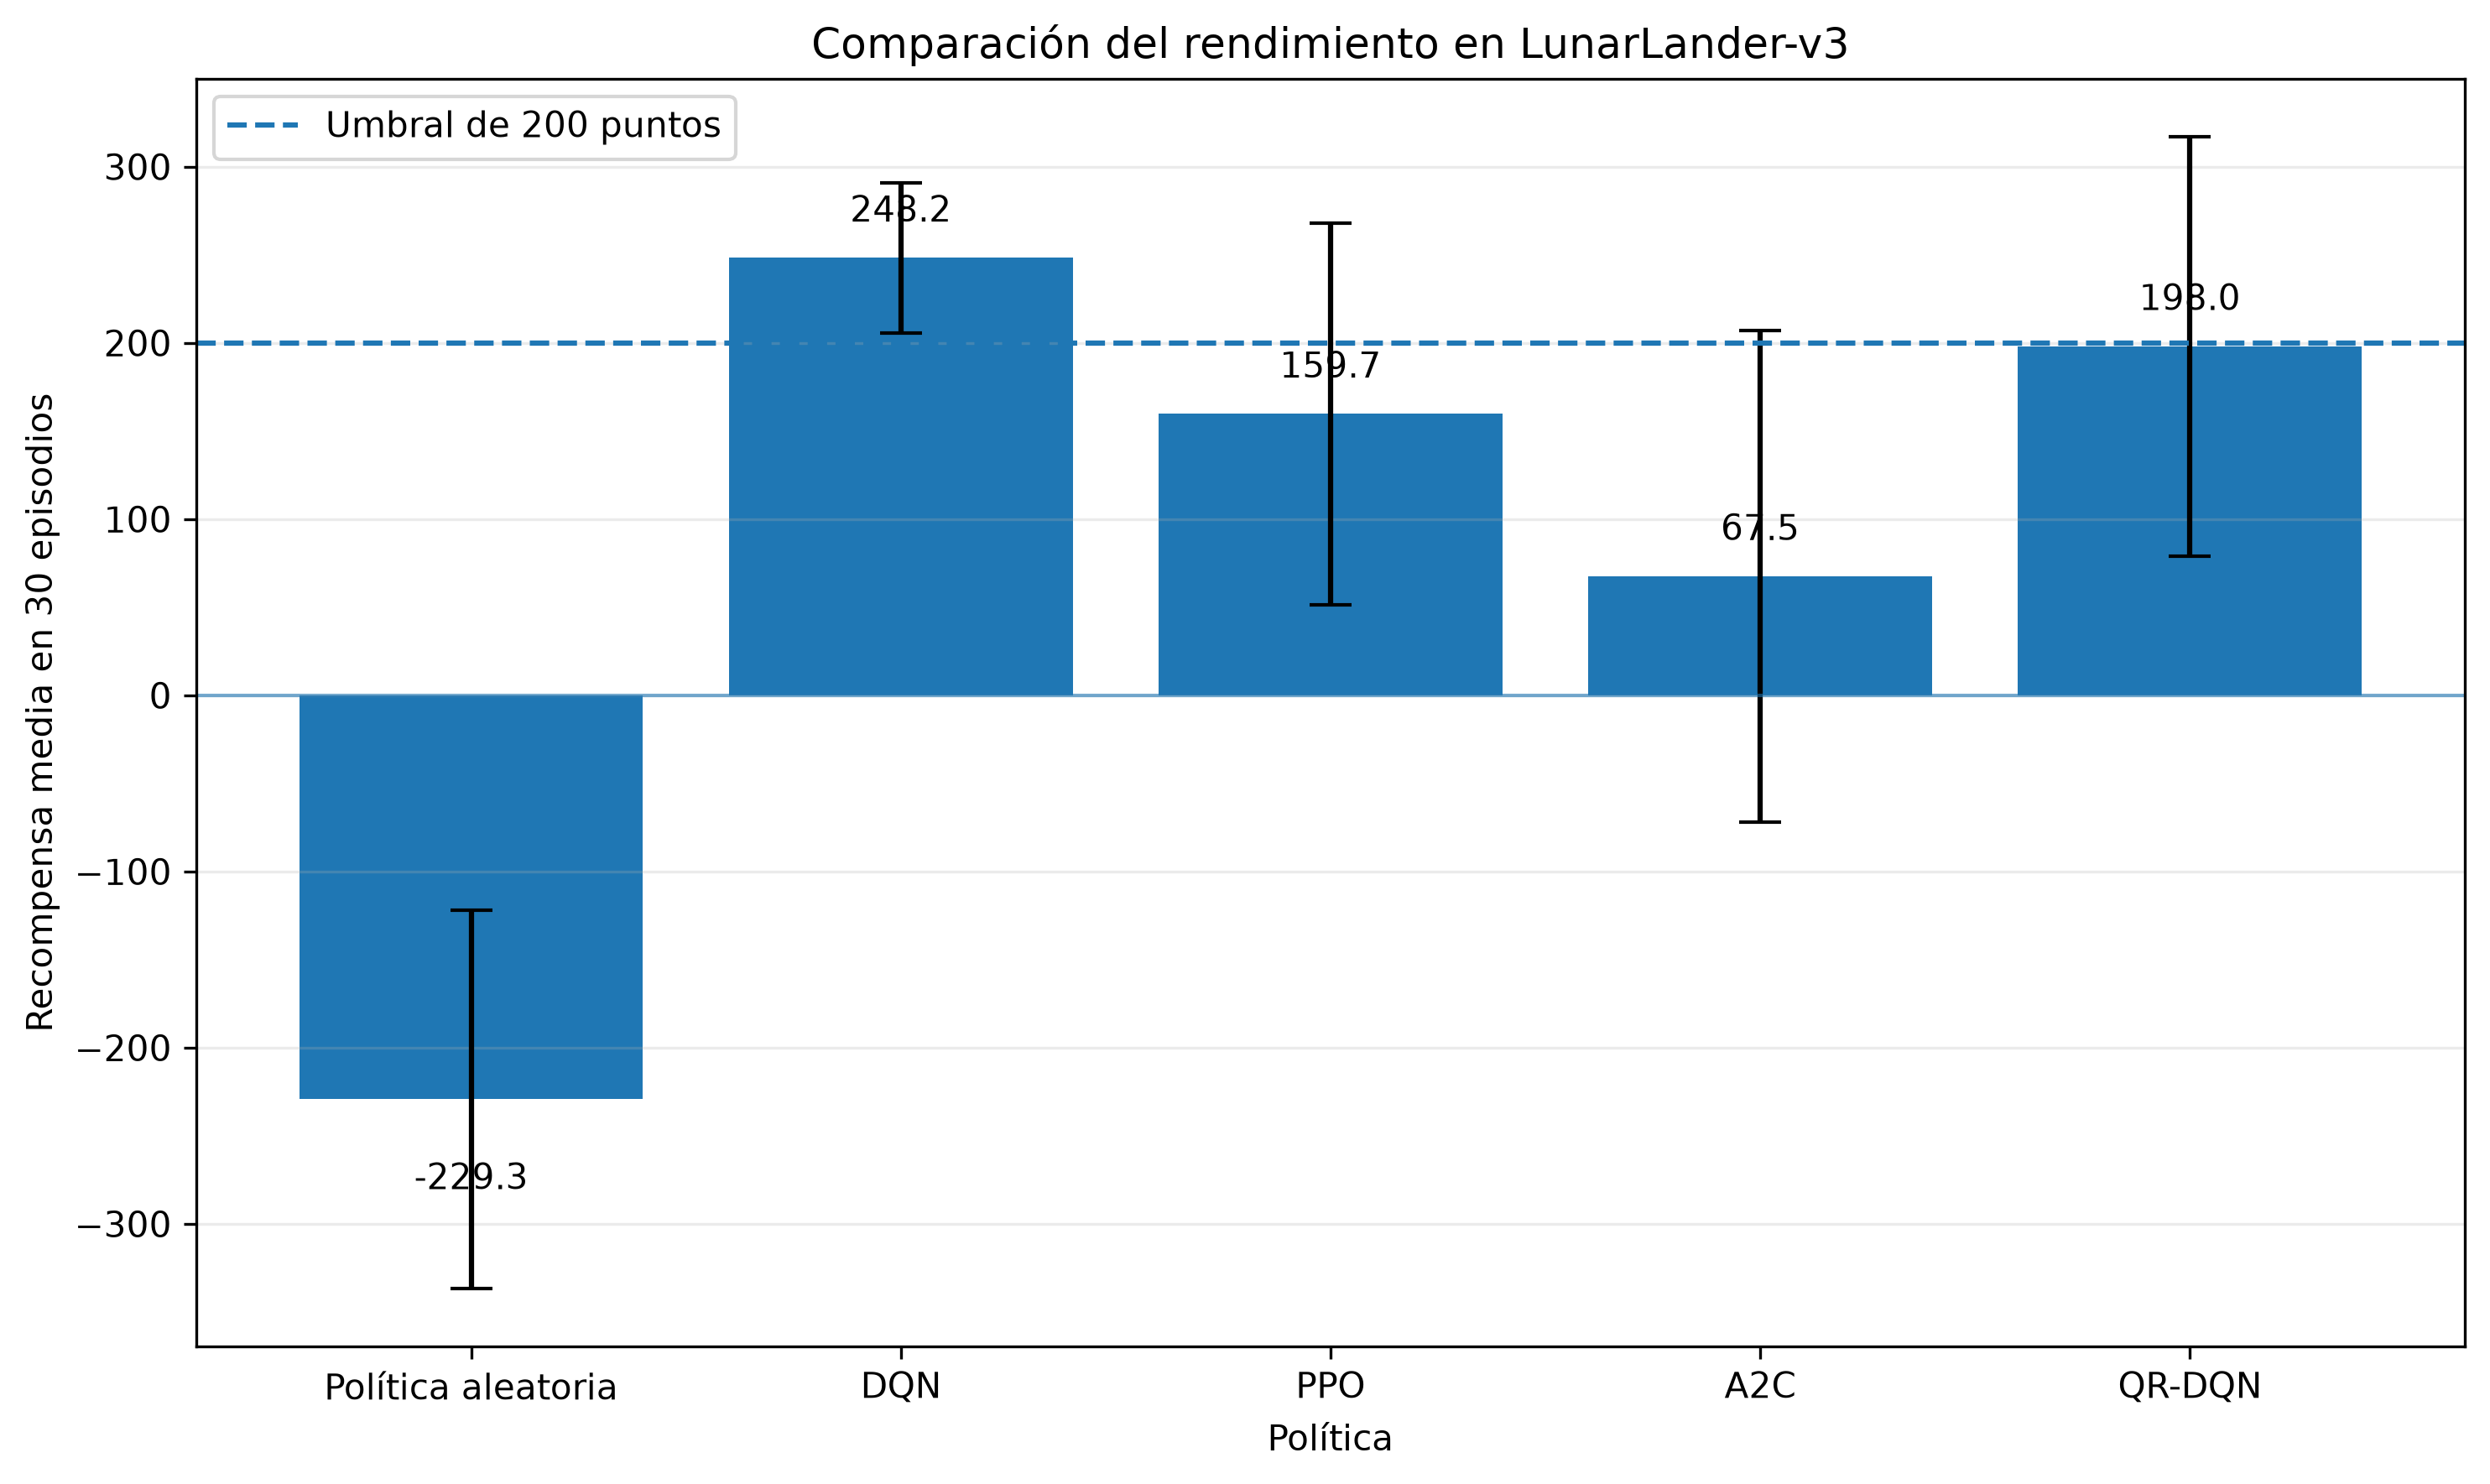

In [29]:
from IPython.display import Image

display(Image(filename=str(
    RUTAS["comparacion"] / "comparacion_recompensas_lunarlander.png"
)))

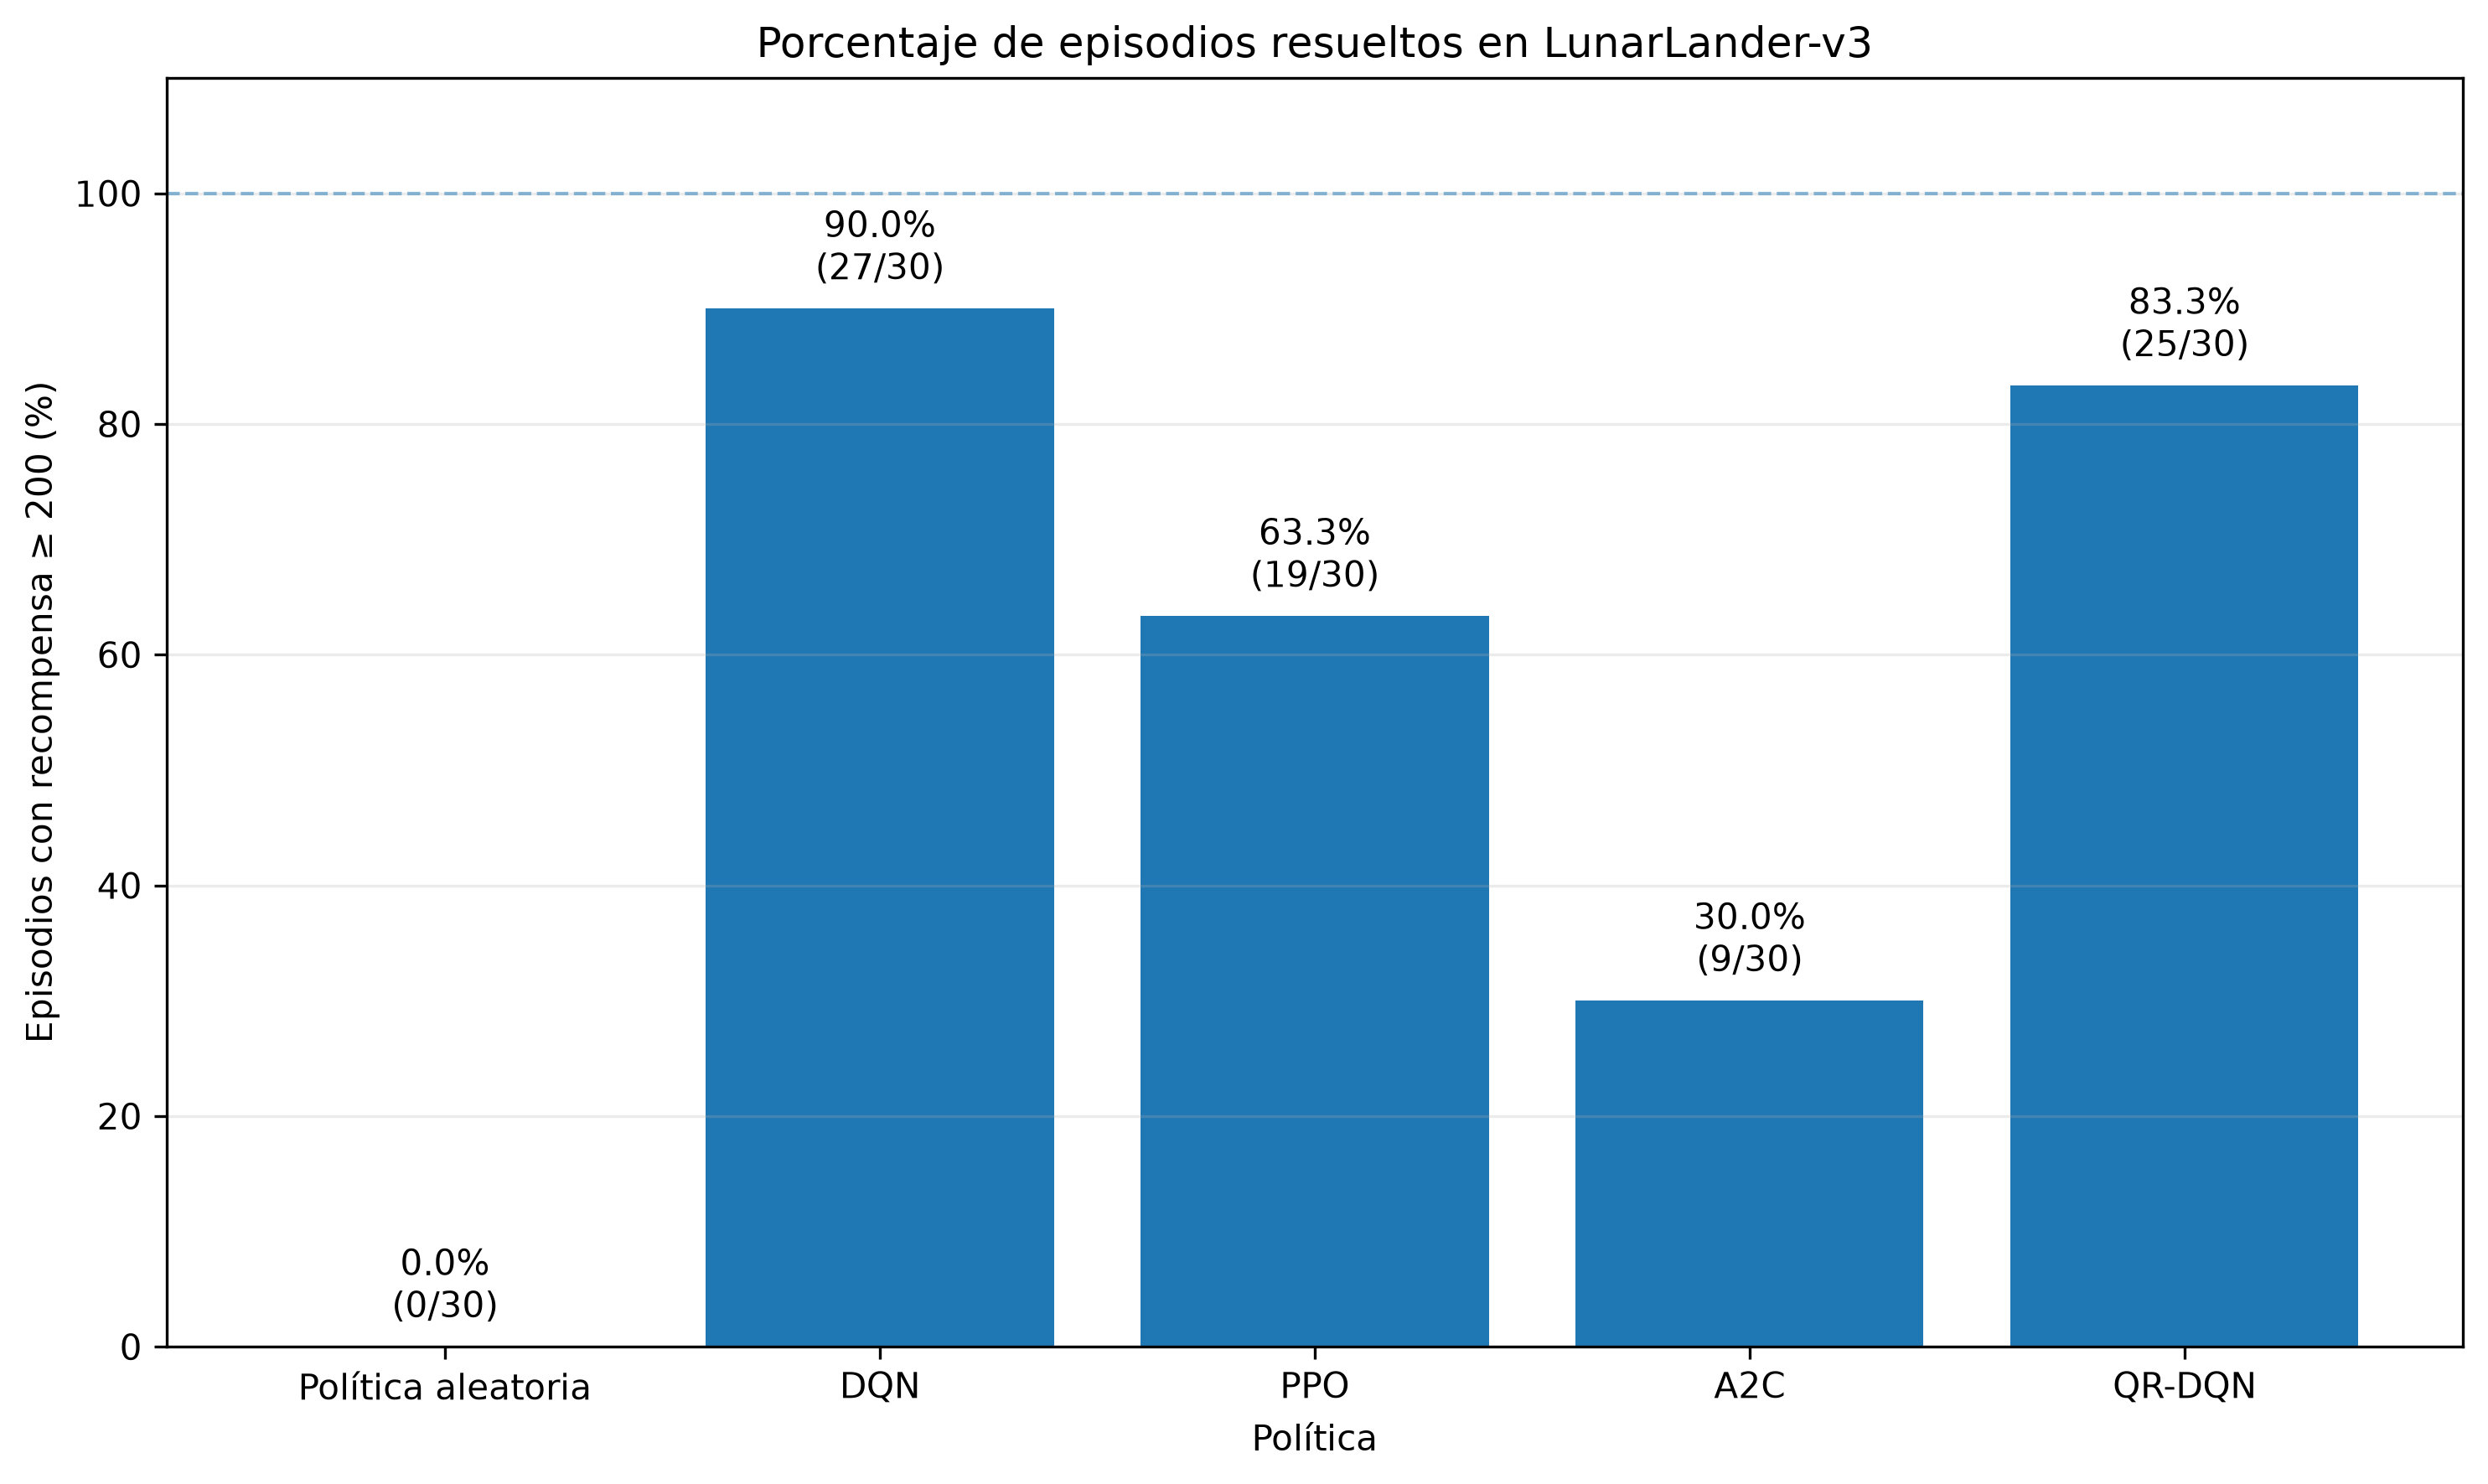

In [30]:
display(Image(filename=str(
    RUTAS["comparacion"] / "comparacion_porcentaje_exito_lunarlander.png"
)))

In [31]:
comparacion_por_semilla = pd.read_csv(
    RUTAS["comparacion"] / "comparacion_recompensas_por_semilla.csv"
)
columnas_modelos = ["politica_aleatoria", "dqn", "ppo", "a2c", "qrdqn"]

victorias_por_politica = (
    comparacion_por_semilla[columnas_modelos]
    .idxmax(axis=1)
    .value_counts()
    .rename_axis("politica")
    .reset_index(name="semillas_con_mejor_recompensa")
)

display(victorias_por_politica)

,politica,semillas_con_mejor_recompensa
0,dqn,19
1,qrdqn,10
2,a2c,1


In [32]:
duraciones_entrenamiento = pd.read_csv(
    RUTAS["comparacion"] / "duraciones_entrenamiento.csv"
)
display(duraciones_entrenamiento.round(2))

,algoritmo,timesteps,duracion_minutos
0,DQN,100000,3.39
1,PPO,1000000,15.02
2,A2C,500000,5.84
3,QR-DQN,100000,88.60


## 8. Conclusiones

- **DQN fue el mejor método**: 248.23 puntos, 90 % de éxito y la menor variabilidad entre los agentes entrenados.
- **QR-DQN quedó segundo**: resolvió 25 episodios, pero varios fallos muy negativos redujeron su media a 198.04.
- **PPO aprendió una política útil**, aunque no alcanzó el rendimiento de los métodos basados en valores: 159.70 puntos y 63,33 % de éxito.
- **A2C fue el método más inestable**. La configuración inicial fue la mejor, con 67.47 puntos y 30 % de éxito; los intentos ajustados y las repeticiones con otras semillas no mejoraron el resultado de forma consistente.
- La experiencia con PPO mostró que **una recompensa superior a 200 no garantiza por sí sola un vídeo visualmente representativo**. Para los vídeos finales se añadió el requisito de apoyar ambas patas y terminar cerca del centro.
- La selección por **mejor checkpoint** fue esencial: una evaluación puntual o el modelo final no siempre representan la política que mejor generaliza.

In [33]:
archivos_esenciales = {
    "Resumen comparativo": RUTAS["comparacion"] / "resumen_comparativo_lunarlander.csv",
    "Figura de recompensas": RUTAS["comparacion"] / "comparacion_recompensas_lunarlander.png",
    "Figura de éxito": RUTAS["comparacion"] / "comparacion_porcentaje_exito_lunarlander.png",
    "Vídeo aleatorio": ruta_video_aleatorio,
    "Vídeo DQN": ruta_video_dqn,
    "Vídeo PPO": ruta_video_ppo,
    "Vídeo A2C": ruta_video_a2c,
    "Vídeo QR-DQN": ruta_video_qrdqn,
}

for nombre, ruta in archivos_esenciales.items():
    print(f"{'✅' if Path(ruta).exists() else '❌'} {nombre}: {ruta}")

✅ Resumen comparativo: /home/andy/Descargas/AR_practica2/lunarlander/resultados_lunarlander/comparacion/resumen_comparativo_lunarlander.csv
✅ Figura de recompensas: /home/andy/Descargas/AR_practica2/lunarlander/resultados_lunarlander/comparacion/comparacion_recompensas_lunarlander.png
✅ Figura de éxito: /home/andy/Descargas/AR_practica2/lunarlander/resultados_lunarlander/comparacion/comparacion_porcentaje_exito_lunarlander.png
✅ Vídeo aleatorio: /home/andy/Descargas/AR_practica2/lunarlander/resultados_lunarlander/politica_aleatoria/videos/lunarlander_politica_aleatoria-episode-0.mp4
✅ Vídeo DQN: /home/andy/Descargas/AR_practica2/lunarlander/resultados_lunarlander/dqn/videos/lunarlander_dqn_mejor-episode-0.mp4
✅ Vídeo PPO: /home/andy/Descargas/AR_practica2/lunarlander/resultados_lunarlander/ppo/videos/lunarlander_ppo_mejor-episode-0.mp4
✅ Vídeo A2C: /home/andy/Descargas/AR_practica2/lunarlander/resultados_lunarlander/a2c/videos/lunarlander_a2c_mejor-episode-0.mp4
✅ Vídeo QR-DQN: /home/a